In [ ]:
import pandas as pd
import kagglehub
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

Import the Dataset

In [3]:
path = kagglehub.dataset_download("naofilahmad/sales-datset-product-sample")
print("Path to dataset files:", path)
df = pd.read_csv(path + "/Sales Data.csv")

Path to dataset files: C:\Users\titin\.cache\kagglehub\datasets\naofilahmad\sales-datset-product-sample\versions\1


In [ ]:
#Cleaning
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df["Order Date"] = pd.to_datetime(df["Order Date"])
# checked for null values and found none, just these edits to clean up the data

C:\Users\titin\AppData\Local\Temp\ipykernel_5576\285028685.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


Inspect the Data
E.g., Display the first few rows using .head() to get a quick overview.
E.g., Use .info() and .describe() to understand data types and summary statistics.
E.g., Check for missing values and duplicates (optional).

In [5]:
# 1. Quick overview
print("First few rows of the DataFrame:")
print(df.head())

First few rows of the DataFrame:
   Order ID       Product Category               Product  Quantity Ordered  \
0    295665  Laptops and Computers    Macbook Pro Laptop                 1   
1    295666        Home Appliances    LG Washing Machine                 1   
2    295667        Charging Cables  USB-C Charging Cable                 1   
3    295668               Monitors      27in FHD Monitor                 1   
4    295669        Charging Cables  USB-C Charging Cable                 1   

   Price Each          Order Date                        Purchase Address  \
0     1700.00 2019-12-30 00:01:00  136 Church St, New York City, NY 10001   
1      600.00 2019-12-29 07:03:00     562 2nd St, New York City, NY 10001   
2       11.95 2019-12-12 18:21:00    277 Main St, New York City, NY 10001   
3      149.99 2019-12-22 15:13:00     410 6th St, San Francisco, CA 94016   
4       11.95 2019-12-18 12:38:00           43 Hill St, Atlanta, GA 30301   

   Month    Sales            City  

In [6]:

# 2. Data types and summary stats
print("Information about the DataFrame:")
df.info()

print("\nSummary statistics:")
print(df.describe(include=["object", "str"]))

Information about the DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  int64         
 1   Product Category  185950 non-null  str           
 2   Product           185950 non-null  str           
 3   Quantity Ordered  185950 non-null  int64         
 4   Price Each        185950 non-null  float64       
 5   Order Date        185950 non-null  datetime64[us]
 6   Purchase Address  185950 non-null  str           
 7   Month             185950 non-null  int64         
 8   Sales             185950 non-null  float64       
 9   City              185950 non-null  str           
 10  Hour              185950 non-null  int64         
 11  Time of Day       185950 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(4), str(5)
memory usage: 17.0 MB

Summary statistics

Basic Filtering and Grouping
Apply filters to extract meaningful subsets of the data.
Use groupby() or equivalent on a selected variable and compute summary statistics (e.g., mean, count).

In [7]:
print("Columns:", df.columns.tolist())

Columns: ['Order ID', 'Product Category', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour', 'Time of Day']


In [8]:
# Orders from a specific city
sf_orders = df[df["City"] == " Boston"]
print(f"\nOrders from Boston: {len(sf_orders)} ")

sf_orders = df[df["City"] == " New York City"]
print(f"\nOrders from New York City: {len(sf_orders)} ")


Orders from Boston: 19934 

Orders from New York City: 24876 


In [ ]:
# Average price, total quantity, total sales, order count per category
category_summary = df.groupby("Product Category").agg(
    avg_price=("Price Each", "mean"),
    total_quantity=("Quantity Ordered", "sum"),
    total_sales=("Sales", "sum"),
    order_count=("Order ID", "count")
).sort_values("total_sales", ascending=False)

print("\nSummary by Product Category:")
print(category_summary)

# Average sale amount by time of day
time_of_day_avgs = df.groupby("Time of Day")["Sales"].mean().sort_values(ascending=False)
print("\nAverage sale amount by Time of Day:")
print(time_of_day_avgs)

# Total sales by month
monthly_sales = df.groupby("Month")["Sales"].sum()
print("\nTotal sales by Month:")
print(monthly_sales)


Summary by Product Category:
                          avg_price  total_quantity  total_sales  order_count
Product Category                                                             
Laptops and Computers   1373.560633            8858  12167558.70         8852
Phones and Accessories   618.791574           14449   8940700.00        14432
Monitors                 264.598851           24122   6377228.78        24019
Audio Devices             81.479017           49675   3941193.86        47756
Entertainment Devices    300.000000            4819   1445700.00         4800
Home Appliances          600.000000            1312    787200.00         1312
Charging Cables           13.441564           47192    633595.40        43561
Batterie                   3.414340           58652    198859.23        41218

Total sales by City:
City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           276797

Explore a Machine Learning Algorithm
Choose an ML algorithm.
Begin experimenting with model inputs and outputs.

In [22]:
# Aggregate sales by Month and Product Category
monthly_category_sales = df.groupby(["Product Category", "Month"])["Sales"].sum().reset_index()

trend_results = []

for category in monthly_category_sales["Product Category"].unique():
    subset = monthly_category_sales[monthly_category_sales["Product Category"] == category]

    X = subset[["Month"]]        # input: month number
    y = subset["Sales"]          # output: total sales that month

    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]       # positive = trending up, negative = trending down
    trend_results.append({"Product Category": category, "monthly_trend_slope": slope})

trend_df = pd.DataFrame(trend_results).sort_values("monthly_trend_slope", ascending=False)
print("\nProduct categories ranked by sales trend (positive = growing):")
print(trend_df)


Product categories ranked by sales trend (positive = growing):
         Product Category  monthly_trend_slope
5   Laptops and Computers         48499.852028
7  Phones and Accessories         29468.181818
6                Monitors         25134.751818
0           Audio Devices         15223.383497
3   Entertainment Devices          6395.454545
2         Charging Cables          2492.954545
4         Home Appliances          1586.013986
1                Batterie           810.147517


Visualization
Create one plot (e.g., histogram, boxplot, scatter plot) using Matplotlib, Seaborn, or others.
Documentation
Explain your steps and findings in a README.md file.

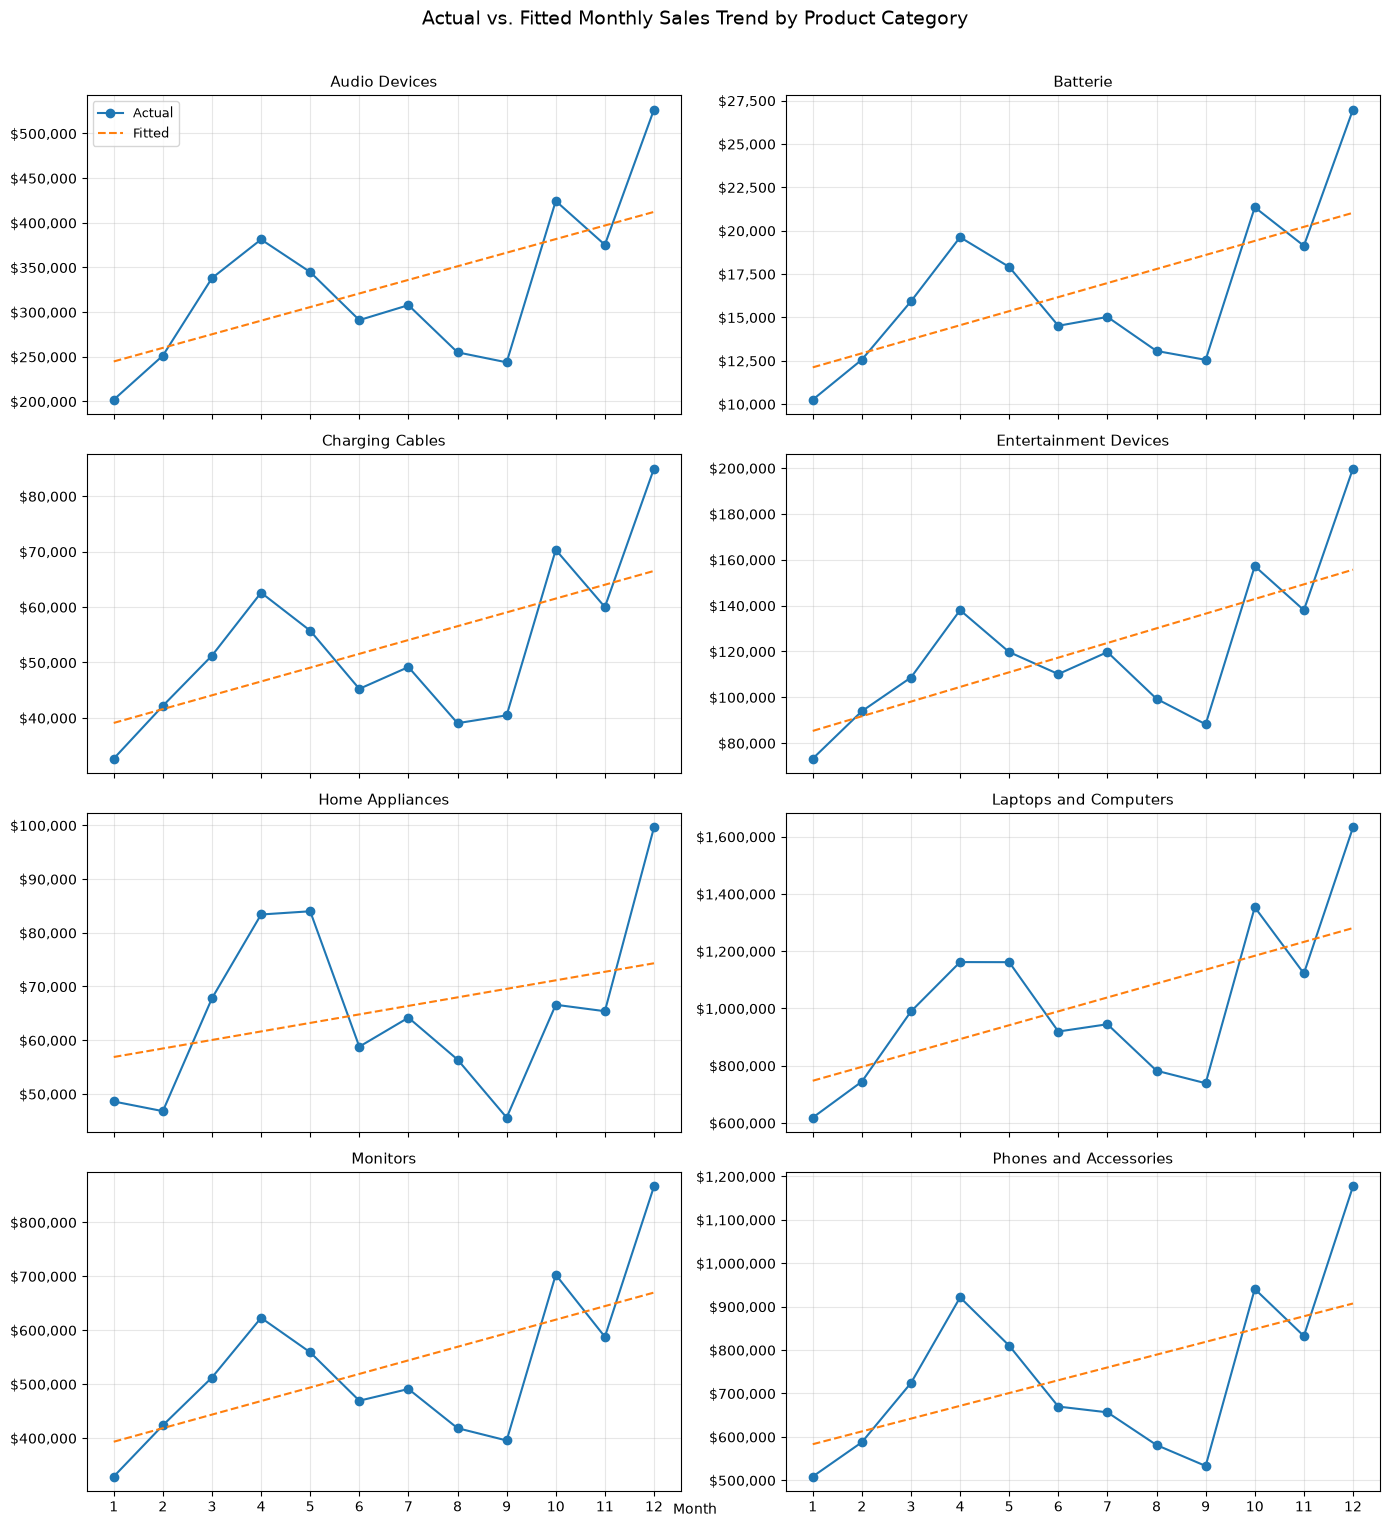

In [23]:
categories = monthly_category_sales["Product Category"].unique()

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    subset = monthly_category_sales[monthly_category_sales["Product Category"] == category].sort_values("Month")
    X = subset[["Month"]]
    y = subset["Sales"]

    model = LinearRegression().fit(X, y)
    predicted = model.predict(X)

    ax.plot(subset["Month"], y, marker="o", label="Actual")
    ax.plot(subset["Month"], predicted, linestyle="--", label="Fitted")
    ax.set_title(category, fontsize=11)
    ax.set_xticks(range(1, 13))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Actual vs. Fitted Monthly Sales Trend by Product Category", fontsize=14)
fig.text(0.5, 0.04, "Month", ha="center")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("all_categories_trend.png", dpi=150)
plt.show()

> I know I was only supposed to do one visualization, but I was curious and wanted to see the trends for all catagories.

> bonus below, because my previous charts raised a few alternate questions

In [ ]:
# Extend the monthly aggregation to include order count
monthly_category_stats = df.groupby(["Product Category", "Month"]).agg(
    total_sales=("Sales", "sum"),
    order_count=("Order ID", "count")
).reset_index()

monthly_category_stats["avg_order_value"] = (
    monthly_category_stats["total_sales"] / monthly_category_stats["order_count"]
)

trend_results = []

for category in monthly_category_stats["Product Category"].unique():
    subset = monthly_category_stats[monthly_category_stats["Product Category"] == category]
    X = subset[["Month"]]

    sales_slope = LinearRegression().fit(X, subset["total_sales"]).coef_[0]
    order_slope = LinearRegression().fit(X, subset["order_count"]).coef_[0]
    avg_value_slope = LinearRegression().fit(X, subset["avg_order_value"]).coef_[0]

    trend_results.append({
        "Product Category": category,
        "sales_trend": sales_slope,
        "order_count_trend": order_slope,
        "avg_order_value_trend": avg_value_slope
    })

trend_df_extended = pd.DataFrame(trend_results).sort_values("sales_trend", ascending=False)
print(trend_df_extended)

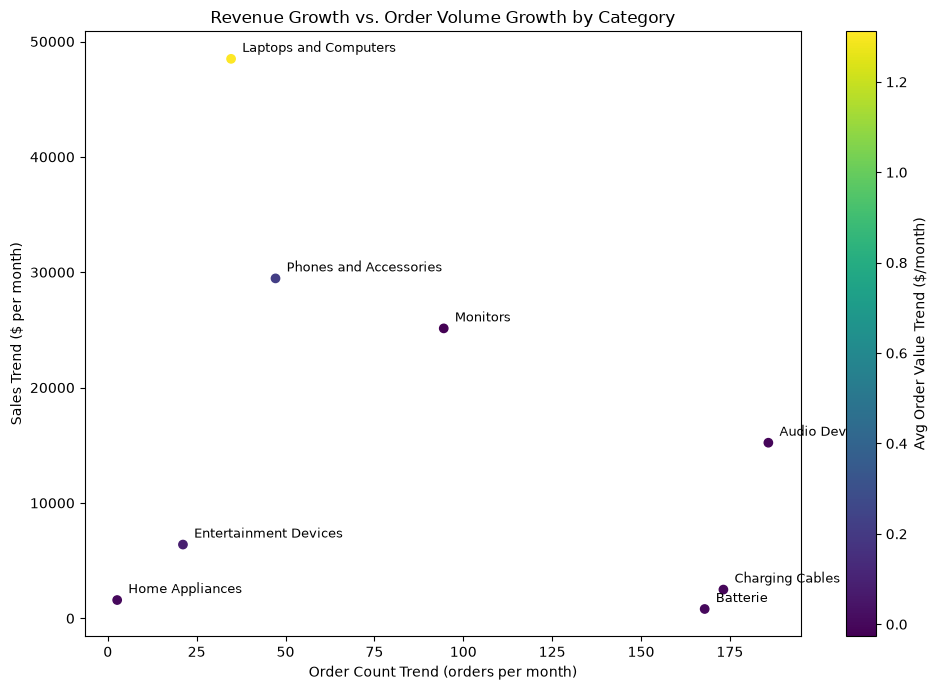

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    trend_df_extended["order_count_trend"],
    trend_df_extended["sales_trend"],
    c=trend_df_extended["avg_order_value_trend"],
)

for _, row in trend_df_extended.iterrows():
    ax.annotate(row["Product Category"],
                (row["order_count_trend"], row["sales_trend"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xlabel("Order Count Trend (orders per month)")
ax.set_ylabel("Sales Trend ($ per month)")
ax.set_title("Revenue Growth vs. Order Volume Growth by Category")
cbar = plt.colorbar(scatter)
cbar.set_label("Avg Order Value Trend ($/month)")
plt.tight_layout()
plt.savefig("trend_scatter.png", dpi=150)
plt.show()